# 02 — Sampling Design

**Goal:** Design and compare sampling strategies for a hypothetical platform corpus of 10M items.
Show concretely why proportional sampling fails for rare harm verticals and how Neyman optimal
and risk-score-stratified designs dramatically reduce required sample sizes.

**Key outputs:**
- Sample size comparison table: SRS vs stratified vs risk-stratified
- Interactive table: sample size × CI width × labeling cost
- Design effect (DEFF) analysis

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from src.sampling import StratifiedHarmSampler, SampleDesign

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
SEED = 42

# ── Configuration ──────────────────────────────────────────────────────────
CORPUS_SIZE = 10_000_000      # Hypothetical platform corpus
COST_PER_LLM_LABEL = 0.001   # USD per LLM classification
CONFIDENCE_LEVEL = 0.95

# Harm verticals with approximate true prevalence rates (from BeaverTails EDA)
HARM_VERTICALS = {
    'sexual_content_minors': 0.004,
    'violent_extremism':     0.011,
    'self_harm_suicide':     0.021,
    'influence_operations':  0.019,
    'platform_abuse':        0.065,
}

sampler = StratifiedHarmSampler(confidence_level=CONFIDENCE_LEVEL)
print('Config loaded. Corpus size:', f'{CORPUS_SIZE:,}')

Config loaded. Corpus size: 10,000,000


## 1. Baseline: Simple Random Sampling

First, compute what SRS would require for each vertical at different CI targets.

In [2]:
ci_targets = [0.010, 0.005, 0.002, 0.001]

srs_table = []
for vertical, prev in HARM_VERTICALS.items():
    row = {'harm_vertical': vertical, 'true_prevalence': prev}
    for ci in ci_targets:
        n = sampler.minimum_sample_size_srs(prev, ci)
        expected_pos = n * prev
        row[f'n_srs_±{ci:.1%}'] = n
        row[f'expected_pos_±{ci:.1%}'] = round(expected_pos, 1)
    srs_table.append(row)

srs_df = pd.DataFrame(srs_table)
print('SRS sample size requirements:')
srs_df

SRS sample size requirements:


,harm_vertical,true_prevalence,n_srs_±1.0%,expected_pos_±1.0%,n_srs_±0.5%,expected_pos_±0.5%,n_srs_±0.2%,expected_pos_±0.2%,n_srs_±0.1%,expected_pos_±0.1%
0,sexual_content_minors,0.004,154,0.6,613,2.5,3827,15.3,15305,61.2
1,violent_extremism,0.011,418,4.6,1672,18.4,10448,114.9,41792,459.7
2,self_harm_suicide,0.021,790,16.6,3160,66.4,19745,414.6,78977,1658.5
3,influence_operations,0.019,717,13.6,2865,54.4,17901,340.1,71601,1360.4
4,platform_abuse,0.065,2335,151.8,9339,607.0,58367,3793.9,233465,15175.2


In [3]:
# Highlight: at 0.01% prevalence (sexual_content_minors ~0.4%), even ±1pp CI requires:
vertical = 'sexual_content_minors'
prev = HARM_VERTICALS[vertical]
n_srs = sampler.minimum_sample_size_srs(prev, 0.005)
expected = n_srs * prev
print(f'{vertical} ({prev:.3%} prevalence):')
print(f'  SRS for ±0.5pp CI: {n_srs:,} items → {expected:.1f} expected positives')
print(f'  Cost at $0.001/label: ${n_srs * COST_PER_LLM_LABEL:,.2f}')
print()
print('Conclusion: at 0.4% prevalence, SRS returns only ~{:.0f} positives — '.format(expected))
print('far too few for reliable CI construction.')

sexual_content_minors (0.400% prevalence):
  SRS for ±0.5pp CI: 613 items → 2.5 expected positives
  Cost at $0.001/label: $0.61

Conclusion: at 0.4% prevalence, SRS returns only ~2 positives — 
far too few for reliable CI construction.


## 2. Stratified Sampling: Three Designs Compared

We partition the corpus into two strata:
- **High-risk (10% of corpus):** Items flagged by a cheap pre-filter (keyword match or prior ML score)
- **Low-risk (90% of corpus):** Everything else

The high-risk stratum is assumed to contain ~80% of all harmful content.

In [4]:
TARGET_CI = 0.005  # ±0.5pp
STRATA = {'high_risk': 0.10, 'low_risk': 0.90}
STRATEGIES = ['proportional', 'neyman', 'risk_stratified']

comparison_rows = []
for vertical, prev in HARM_VERTICALS.items():
    n_srs = sampler.minimum_sample_size_srs(prev, TARGET_CI)
    row = {
        'harm_vertical': vertical,
        'true_prevalence': f'{prev:.3%}',
        'n_srs': n_srs,
        'cost_srs_usd': n_srs * COST_PER_LLM_LABEL,
    }
    for strategy in STRATEGIES:
        design = sampler.design_sample(
            corpus_size=CORPUS_SIZE,
            estimated_prevalence=prev,
            target_ci_width=TARGET_CI,
            strata_weights=STRATA,
            labeling_cost_per_item=COST_PER_LLM_LABEL,
            strategy=strategy,
        )
        row[f'n_{strategy}'] = design.n_total
        row[f'cost_{strategy}_usd'] = design.expected_cost_usd
        row[f'deff_{strategy}'] = round(design.design_effect, 2)
    comparison_rows.append(row)

comp_df = pd.DataFrame(comparison_rows)
comp_df

,harm_vertical,true_prevalence,n_srs,cost_srs_usd,n_proportional,cost_proportional_usd,deff_proportional,n_neyman,cost_neyman_usd,deff_neyman,n_risk_stratified,cost_risk_stratified_usd,deff_risk_stratified
0,sexual_content_minors,0.400%,613,0.613,613,0.613,0.98,304,0.304,0.50,304,0.304,0.58
1,violent_extremism,1.100%,1672,1.672,1672,1.672,0.94,814,0.814,0.49,814,0.814,0.58
2,self_harm_suicide,2.100%,3160,3.160,3160,3.160,0.88,1498,1.498,0.47,1498,1.498,0.57
3,influence_operations,1.900%,2865,2.865,2864,2.864,0.90,1365,1.365,0.48,1365,1.365,0.57
4,platform_abuse,6.500%,9339,9.339,9339,9.339,0.62,3802,3.802,0.41,3802,3.802,0.54


In [5]:
# Compute relative efficiency (SRS cost / stratified cost)
comp_df['efficiency_neyman'] = comp_df['n_srs'] / comp_df['n_neyman']
comp_df['efficiency_risk'] = comp_df['n_srs'] / comp_df['n_risk_stratified']

print('Efficiency gains vs SRS (>1 = stratified requires fewer samples):')
print(comp_df[['harm_vertical', 'true_prevalence', 'efficiency_neyman', 'efficiency_risk']]
      .to_string(index=False))

Efficiency gains vs SRS (>1 = stratified requires fewer samples):
        harm_vertical true_prevalence  efficiency_neyman  efficiency_risk
sexual_content_minors          0.400%           2.016447         2.016447
    violent_extremism          1.100%           2.054054         2.054054
    self_harm_suicide          2.100%           2.109479         2.109479
 influence_operations          1.900%           2.098901         2.098901
       platform_abuse          6.500%           2.456339         2.456339


## 3. Visualization: Sample Size Comparison

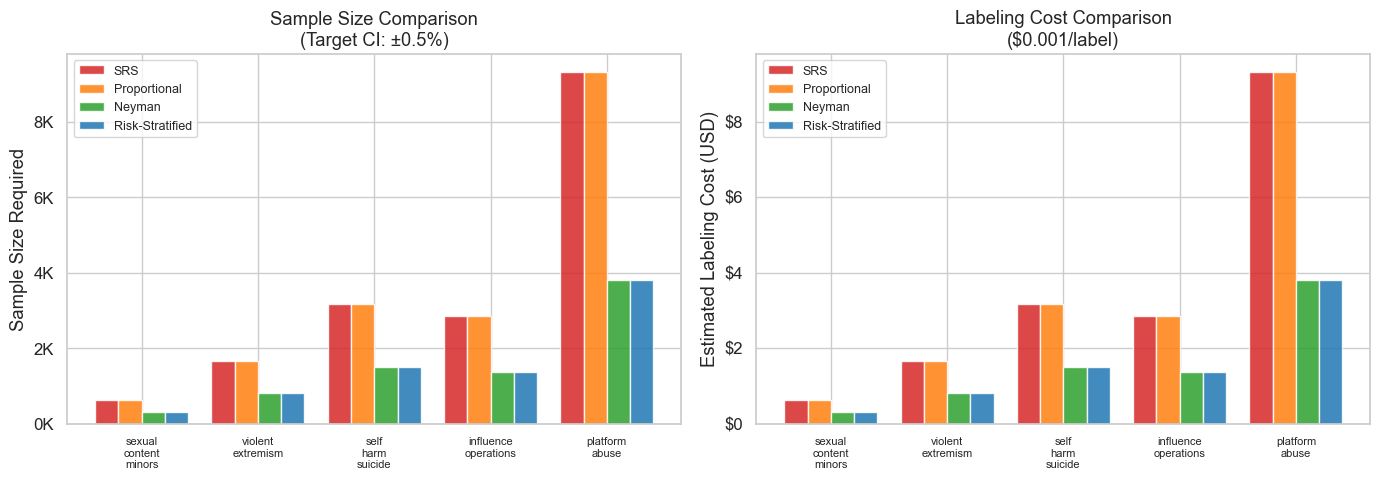

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Sample sizes
ax = axes[0]
x = np.arange(len(HARM_VERTICALS))
width = 0.2
labels = list(HARM_VERTICALS.keys())
short_labels = [l.replace('_', '\n') for l in labels]

ax.bar(x - width*1.5, comp_df['n_srs'], width, label='SRS', color='#d62728', alpha=0.85)
ax.bar(x - width*0.5, comp_df['n_proportional'], width, label='Proportional', color='#ff7f0e', alpha=0.85)
ax.bar(x + width*0.5, comp_df['n_neyman'], width, label='Neyman', color='#2ca02c', alpha=0.85)
ax.bar(x + width*1.5, comp_df['n_risk_stratified'], width, label='Risk-Stratified', color='#1f77b4', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=8)
ax.set_ylabel('Sample Size Required')
ax.set_title(f'Sample Size Comparison\n(Target CI: ±{TARGET_CI:.1%})')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Right: Labeling cost
ax2 = axes[1]
ax2.bar(x - width*1.5, comp_df['cost_srs_usd'], width, label='SRS', color='#d62728', alpha=0.85)
ax2.bar(x - width*0.5, comp_df['cost_proportional_usd'], width, label='Proportional', color='#ff7f0e', alpha=0.85)
ax2.bar(x + width*0.5, comp_df['cost_neyman_usd'], width, label='Neyman', color='#2ca02c', alpha=0.85)
ax2.bar(x + width*1.5, comp_df['cost_risk_stratified_usd'], width, label='Risk-Stratified', color='#1f77b4', alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels(short_labels, fontsize=8)
ax2.set_ylabel('Estimated Labeling Cost (USD)')
ax2.set_title(f'Labeling Cost Comparison\n($0.001/label)')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}'))

plt.tight_layout()
plt.savefig('../data/processed/02_sampling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Sample Size × CI Width × Cost Tradeoff Table

Decision tool for setting the measurement budget for a given harm vertical.

In [7]:
# Focus on the rarest vertical: sexual_content_minors
FOCUS_VERTICAL = 'sexual_content_minors'
FOCUS_PREV = HARM_VERTICALS[FOCUS_VERTICAL]

ci_targets = [0.020, 0.010, 0.005, 0.002, 0.001]

tradeoff_rows = []
for ci in ci_targets:
    for strategy in ['proportional', 'neyman', 'risk_stratified']:
        design = sampler.design_sample(
            corpus_size=CORPUS_SIZE,
            estimated_prevalence=FOCUS_PREV,
            target_ci_width=ci,
            strata_weights=STRATA,
            labeling_cost_per_item=COST_PER_LLM_LABEL,
            strategy=strategy,
        )
        tradeoff_rows.append({
            'target_ci_half_width': f'±{ci:.1%}',
            'strategy': strategy,
            'n_total': design.n_total,
            'cost_usd': design.expected_cost_usd,
            'expected_positives': round(design.n_total * FOCUS_PREV, 1),
            'design_effect': design.design_effect,
        })

tradeoff_df = pd.DataFrame(tradeoff_rows)
print(f'Tradeoff table for {FOCUS_VERTICAL} (π = {FOCUS_PREV:.3%})')
tradeoff_df

Tradeoff table for sexual_content_minors (π = 0.400%)


,target_ci_half_width,strategy,n_total,cost_usd,expected_positives,design_effect
0,±2.0%,proportional,100,0.100,0.4,0.978125
1,±2.0%,neyman,100,0.100,0.4,0.495305
2,±2.0%,risk_stratified,100,0.100,0.4,0.580981
3,±1.0%,proportional,154,0.154,0.6,0.998276
4,±1.0%,neyman,100,0.100,0.4,0.495305
5,±1.0%,risk_stratified,100,0.100,0.4,0.580981
6,±0.5%,proportional,613,0.613,2.5,0.981790
7,±0.5%,neyman,304,0.304,1.2,0.495260
8,±0.5%,risk_stratified,304,0.304,1.2,0.579766
9,±0.2%,proportional,3827,3.827,15.3,0.977169


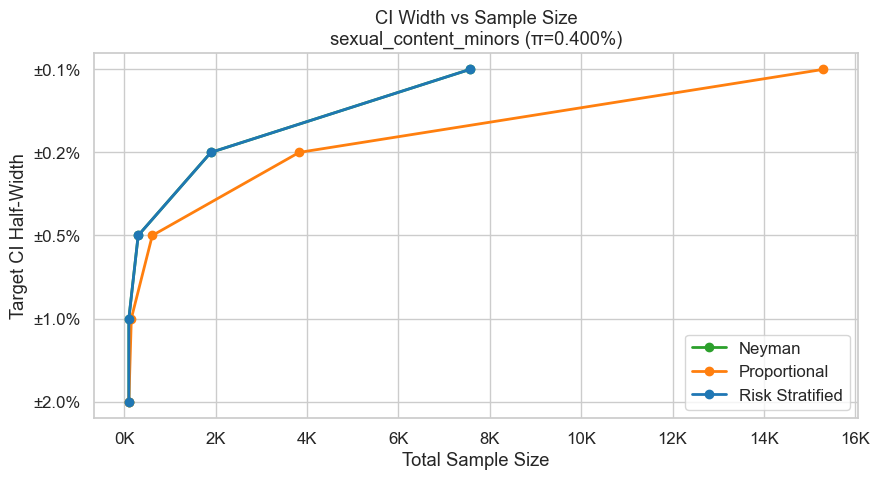

In [8]:
# Visualize tradeoff: CI width vs sample size by strategy
fig, ax = plt.subplots(figsize=(9, 5))

colors_strategy = {'proportional': '#ff7f0e', 'neyman': '#2ca02c', 'risk_stratified': '#1f77b4'}

for strategy, group in tradeoff_df.groupby('strategy'):
    ax.plot(
        group['n_total'], group['target_ci_half_width'],
        marker='o', label=strategy.replace('_', ' ').title(),
        color=colors_strategy[strategy], lw=2
    )

ax.set_xlabel('Total Sample Size')
ax.set_ylabel('Target CI Half-Width')
ax.set_title(f'CI Width vs Sample Size\n{FOCUS_VERTICAL} (π={FOCUS_PREV:.3%})')
ax.legend()
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../data/processed/02_tradeoff_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Design Recommendations

| Vertical | Recommended Strategy | Rationale |
|---------|---------------------|----------|
| sexual_content_minors | Risk-stratified | Extreme rarity; pre-filter essential |
| violent_extremism | Risk-stratified | Low prevalence; keyword pre-filter available |
| self_harm_suicide | Neyman | Moderate rarity; benefits from σ-based allocation |
| influence_operations | Neyman | Moderate rarity; temporal clustering present |
| platform_abuse | Proportional | High enough prevalence for SRS to be feasible |

**Next step:** `03_prevalence_estimation.ipynb` — apply all three estimators to the sampled data.